# Constante van Planck bepalen

# Labjournaal 
## General

**Names: Pieter Broerse & Frederik Roerink**  

**Title of the experiment: Constante van Planck bepaling**  

**Starting date: 08/01/2025**  

**Expected enddate: 23/01/2025**  

**Goal of the experiment: Bepalen van de constante van Planck met de golflengte en knee-voltage van verschillende LED's** 

**Research question: Is de constante van Planck nauwkeurig te bepalen met de golflengte en knee-voltage van verschillende LED's?**  

**Expectations or Hypothesis: We verwachten dat de gevonden waarde uit de experimenten niet strijdig is met de literatuurwaarde voor de constante van Planck**  

**Desired accuracy: 5%**  

In [76]:
# Importing important data sets
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import curve_fit

# De golflengte bereken van alle kleuren van de regenboog


## Preparation
 

**Assignments:**  N.v.t

**Method:** In dit experiment wordt de golflengte van verschillende LED's bepaald met behulp van een diffractierooster. Het experiment maakt gebruik van een niet symmetrische opstelling, waarbij de invallende lichtstraal niet loodrecht op het rooster staat. Hierdoor moet de diffractiehoek worden bepaald met behulp van geometrie.

**Theory:** Voor een diffractierooster geldt:

$$ d*sin(i) + m*\lambda = d*sin(u_m) $$

waarbij:
- $m$ het orde getal (hier steeds m=1)
- $d$ de roosterafstand
- $i$ de invalshoek van het licht
- $u_m$ de uitvalshoek van het licht

De hoek $u_m$ kan niet direct worden afgelezen, maar wordt bepaald met behulp van geometrie uit de gemeten afstanden $a$,$d$ en $L$, zoals weergegeven in Fig 1. Omdat het scherm loodrecht op de lichtbundel staat, volgt voor de uitvalshoek:

$$ u_m = arctan((a+d)/L) - 1/2*arctan(a/L) $$

Met deze hoek wordt vervolgens de golflengte van het licht berekend.


**Independent variable:** De kleur van de LED (rood,oranje,geel,groen,blauw, en paars) 

**Dependent variable:**  De golflengte $\lambda$ van het licht (in nanometers)

**Controlled variables:** 
- Type en kwaliteit van het diffractierooster
- Intensiteit van de lichtbron
- Afstand $L$ tussen rooster en sherm
- Omgevingslicht
- Geometrische uitlijning van de opstelling
- Orde getal $m$ = 1


**Measurement instruments \& Settings:** 
- Diffractierooster (met bekende roosterafstand $d$)
- Lichbron 
- Meetlat of liniaal om $x$ te meten
- Gradenboog

**Procedure:** 
1. Plaats de LED achter een spleet en lens zodat een evenwijdige lichtbundel ontstaat.
2. Laat het licht onder een vaste invalshoek op het diffractierooster vallen.
3. Plaats het scherm op een afstand $L$ achter het rooster
4. Bepaal op het scherm:
- de positie van orde 0
- de positie van de eerste orde
5. Meet de afstanden $a$ en $d$ zoals weergegeven in Fig 1.
6. Bereken de uitvalshoek $u_m$
7. Bereken de golflengte $\lambda$
8. Herhaal dit voor elke LED-kleur


**Notes:**
- Meet meerdere keren voor elke kleur en neem het gemiddelde voor nauwkeurigheid
- Houd het zo donker mogelijk tijdens metingen
- Zorg dat het diffractierooster schoon is en stabiel staat.  




## Opstelling: 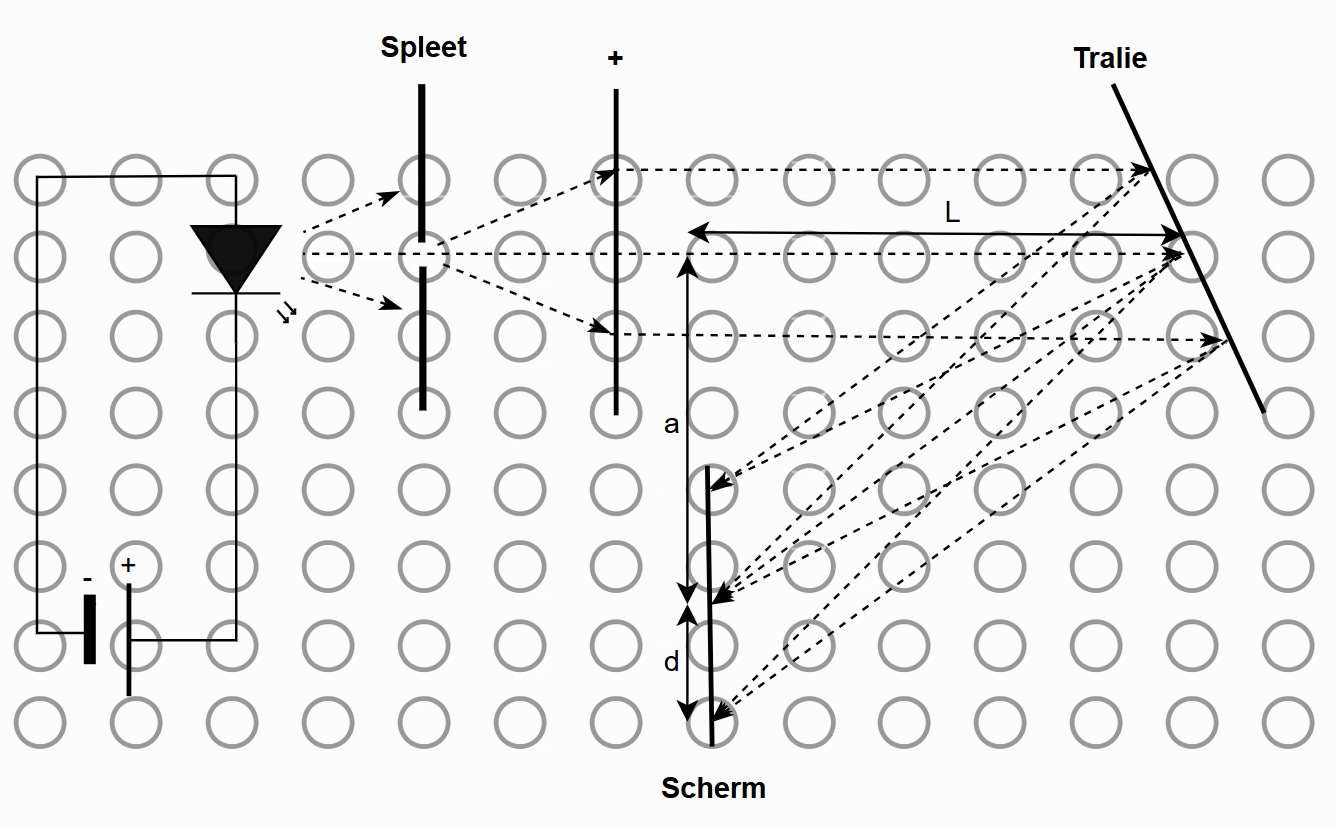

In [77]:
Diffcratierooster = 600  # lijnen / mm
d = (1/600 )* 1e-3       # roosterafstand in meter

L = 0.30                 # meter tot de meetplaat
i_deg = 20               # invalshoek in graden
i = np.deg2rad(i_deg)    # invalshoek in radialen
m = 1                    # orde

u_L = 0.02               # onzekerheden
u_x = 0.02
u_a = 0.02

# Functies definieren

def mean(x1,x2,x3):
    return (x1+x2+x3)/3

def um(a,x,L):
    return np.arctan((a+x)/L) - 0.5*np.arctan(a/L)

def golflengte(um_val, i=i, m=m):
    return d * (np.sin(um_val) - np.sin(i)) / m

def golflengte_to_nm(l):
    return l*1e9

def golflengte_onzekerheid(a, x, u_a, u_x, u_L):
    um_val = um(a, x, L)

    # Partiële afgeleide voor onzekerheden
    da = 1/(L * (1 + ((a + x)/L)**2)) - 0.5 / (L * (1 + (a/L)**2))  # derivative w.r.t. a
    dx = 1/(L * (1 + ((a + x)/L)**2))  # derivative w.r.t. x
    dL = -(a + x)/(L**2 * (1 + ((a + x)/L)**2)) + a / (2 * L**2 * (1 + (a/L)**2))  # derivative w.r.t. L

    # Onzekerheid in u_um
    u_um = np.sqrt((da * u_a)**2 + (dx * u_x)**2 + (dL * u_L)**2)

    # Onzekerheid in golflengte
    u_lambda = d * np.cos(um_val) * u_um
    return u_lambda

# De golflengte van rood licht
r_a = 0.50
r_x_1 = 0.63

x_rood = r_x_1
um_r = um(r_a, x_rood, L)
golflengte_r_nm = golflengte_to_nm(golflengte(um_r))
u_r_nm = golflengte_to_nm(golflengte_onzekerheid(r_a, x_rood, u_a, u_x, u_L))  # Calculate uncertainty
print("λ rood =", golflengte_r_nm, "±", u_r_nm, "nm")


# Oranje led 
o_a = 0.51
o_x_1 = 0.61

x_oranje = mean(o_x_1, o_x_2, o_x_3)
um_o = um(o_a, x_oranje, L)
golflengte_o_nm = golflengte_to_nm(golflengte(um_o))
u_o_nm = golflengte_to_nm(golflengte_onzekerheid(o_a, x_oranje, u_a, u_x, u_L))  # Calculate uncertainty
print("λ oranje =", golflengte_o_nm, "±", u_o_nm, "nm")


# Geel led 
g_a = 0.52
g_x_1 = 0.48

x_geel = g_x_1
um_g = um(g_a, x_geel, L)
golflengte_g_nm = golflengte_to_nm(golflengte(um_g))
u_g_nm = golflengte_to_nm(golflengte_onzekerheid(g_a, x_geel, u_a, u_x, u_L))  # Calculate uncertainty
print("λ geel =", golflengte_g_nm, "±", u_g_nm, "nm")


# Groen led 
gr_a = 0.53
gr_x_1 = 0.37

x_groen = gr_x_1
um_gr = um(gr_a, x_groen, L)
golflengte_gr_nm = golflengte_to_nm(golflengte(um_gr))
u_gr_nm = golflengte_to_nm(golflengte_onzekerheid(gr_a, x_groen, u_a, u_x, u_L))  # Calculate uncertainty
print("λ groen =", golflengte_gr_nm, "±", u_gr_nm, "nm")


# Blauw led 
b_a = 0.54
b_x_1 = 0.25

x_blauw = b_x_1
um_b = um(b_a, x_blauw, L)
golflengte_b_nm = golflengte_to_nm(golflengte(um_b))
u_b_nm = golflengte_to_nm(golflengte_onzekerheid(b_a, x_blauw, u_a, u_x, u_L))  # Calculate uncertainty
print("λ blauw =", golflengte_b_nm, "±", u_b_nm, "nm")


# Paars led 
p_a = 0.55
p_x_1 = 0.14

x_paars = mean(p_x_1, p_x_2, p_x_3)
um_p = um(p_a, x_paars, L)
golflengte_p_nm = golflengte_to_nm(golflengte(um_p))
u_p_nm = golflengte_to_nm(golflengte_onzekerheid(p_a, x_paars, u_a, u_x, u_L))  # Calculate uncertainty
print("λ paars =", golflengte_p_nm, "±", u_p_nm, "nm")

λ rood = 621.0309230960291 ± 7.579595318145927 nm
λ oranje = 612.6916202407012 ± 7.548027251224484 nm
λ geel = 572.8186555003232 ± 8.883015392846566 nm
λ groen = 530.4236956509907 ± 11.1306936791946 nm
λ blauw = 472.79075361549053 ± 15.077196563978289 nm
λ paars = 408.42110516932945 ± 20.143313129725446 nm


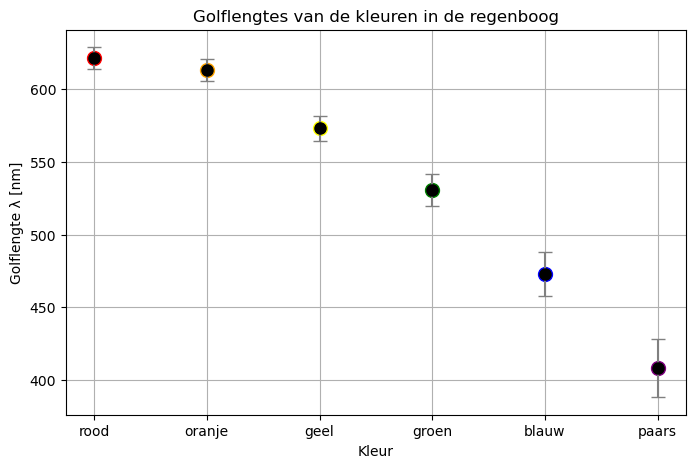

In [78]:
# Alle golflengtes en onzekerheden in lijsten zetten
kleuren_namen = ["rood","oranje","geel","groen","blauw","paars"]
golflengtes_nm = [golflengte_r_nm, golflengte_o_nm, golflengte_g_nm, golflengte_gr_nm, golflengte_b_nm, golflengte_p_nm]
onzekerheden_nm = [u_r_nm, u_o_nm, u_g_nm, u_gr_nm, u_b_nm, u_p_nm]

# Kleuren voor de punten
kleuren_rgb = ['red','orange','yellow','green','blue','purple']

plt.figure(figsize=(8,5))
plt.errorbar(kleuren_namen, golflengtes_nm, yerr=onzekerheden_nm, fmt='o', 
             color='k', ecolor='gray', capsize=5, markersize=8)

# Punten kleuren volgens de kleur van het licht
for i, kleur in enumerate(kleuren_namen):
    plt.scatter(kleur, golflengtes_nm[i], color=kleuren_rgb[i], s=100)

plt.title("Golflengtes van de kleuren in de regenboog")
plt.ylabel("Golflengte λ [nm]")
plt.xlabel("Kleur")
plt.grid(True)
plt.show()

# Knee-voltage bepalen


## Preparation
 

**Assignments:** N.v.t

**Method:**  Het bepalen van de knee-voltage voor enkele lampen gaan we doen door in een donkere kamer te meten bij welk voltage de LED gaat branden. Dit is een eenvoudige opstelling met een spanningsbron, spanningsmeter en een lens waarmee sneller gezien kan worden of het lampje brandt. Met deze knee-voltage en het elementair ladingskwamtum kan vervolgens een grafiek worden gemaakt van de verschillende lampjes tegen de golflengte. Met de trend in deze grafiek wordt de constante van Planck bepaald.

**Theory:**  Iedere led heeft een bepaalde spanning waarbij de LED begint met branden, de knee-voltage. Deze spanning wordt gekaraktiseerd volgens het elementair ladingsquantum en de uitgezonden energie via: 

$$
E = eV_{knee}
$$

Met deze knee-voltage en het elementair ladingsquantum (constant) kan dus voor elke LED de hoeveelheid uitgezonden energie bepaald worden. De energie kan gecombineerd worden met de golflengte in de formule:

$$
E = \frac{hc}{\lambda} 
$$

Hierin is $h$ de constante van Planck en $c$ de snelheid van het licht in vacuüm, $2.998 \times 10^8\ \mathrm{m\,s^{-1}}$. Door de energie van het uitgezonden licht van de LED's tegen de golflengte, kan met een fit de constante van Planck worden bepaald.

**Independent variable:** Spanning V

**Dependent variable:**  Branden van LED

**Controlled variablen:**  Soort LED, omgevingslicht, bedrading, temperatuur

**Measurement instruments \& Settings:** Er wordt gebruik gemaakt van een spanningsbron, 5-digit multimeter, bedrading, houders en een lens

**Procedure:** Elke LED wordt apart aangesloten op de spanningsbron. De spanningsmeter wordt over de LED aangesloten en de spanning wordt opgevoerd totdat het lampje minimaal begint te branden. De spanning waarbij de LED minimaal gaat branden wordt genoteerd.


**Setup(drawing or picture):** 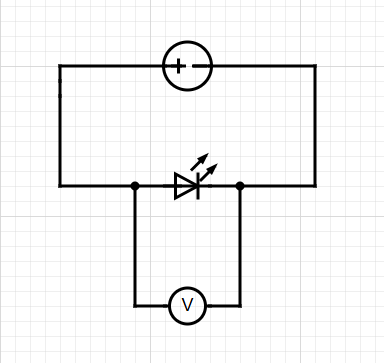  

**Notes:**  

**About accuracy:** 

## Execution

In [117]:
# Measurements
kleuren = ["rood","oranje","geel","groen","blauw","paars"]

#Eerste meting
Vknee1 = [2.236, 2.295, 2.304, 2.537, 2.779, 3.236]

#Tweede meting
Vknee2 = [2.162, 2.100, 2.408, 2.487, 2.685, 3.307]

#Derde meting
Vknee3 = [2.174, 1.984, 2.289, 2.561, 2.799, 3.289]


**Observations:**  

**Notes:**  


## Processing


### Data processing and Fitting

Fitresultaten:
a (h*c) = 2.113771388415993e-25 J·m
b       = 3.250911241530594e-21 J
h_fit   = 7.050605031407582e-34 J·s
h (echt)= 6.62607015e-34 J·s


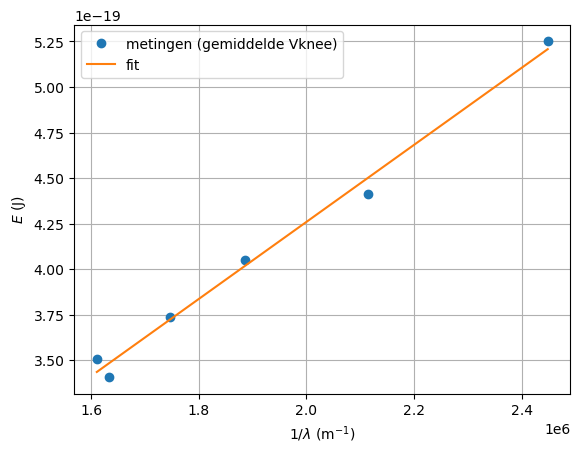

In [118]:
kleuren = ["rood","oranje","geel","groen","blauw","paars"]

lam_nm = np.array([golflengte_r_nm, golflengte_o_nm, golflengte_g_nm, golflengte_gr_nm, golflengte_b_nm, golflengte_p_nm])  # nm
lam_err_nm = np.array([u_r_nm, u_o_nm, u_g_nm, u_gr_nm, u_b_nm, u_p_nm])    # nm

lam_err_m = lam_err_nm * 1e-9    # m
inv_lam_err = lam_err_m / (lam_m**2)   # foutpropagatie

Vknee1 = np.array(Vknee1)
Vknee2 = np.array(Vknee2)
Vknee3 = np.array(Vknee3)

V_err = 0.15                     # V
E_err = e * V_err                # J

# constanten
e = 1.602176634e-19   # C
c = 2.998e8           # m/s

# gemiddeld Vknee 
Vknee = (Vknee1 + Vknee2 + Vknee3) / 3

# x en y voor fit
lam_m = lam_nm * 1e-9
inv_lam = 1 / lam_m             # 1/m

E = e * Vknee                   # Joule

# fitfunctie
def line(x, a, b):
    return a*x + b

# beginwaarden
p0 = (1e-25, 0.0)

params, cov = curve_fit(line, inv_lam, E, p0=p0, sigma = E_err, absolute_sigma=True)
a_fit, b_fit = params

h_fit = a_fit / c

print("Fitresultaten:")
print("a (h*c) =", a_fit, "J·m")
print("b       =", b_fit, "J")
print("h_fit   =", h_fit, "J·s")
print("h (echt)=", 6.62607015e-34, "J·s")

# plot
x_fit = np.linspace(inv_lam.min(), inv_lam.max(), 200)
y_fit = line(x_fit, a_fit, b_fit)

plt.figure()
plt.plot(inv_lam, E, "o", label="metingen (gemiddelde Vknee)")
plt.plot(x_fit, y_fit, "-", label="fit")
plt.xlabel(r"$1/\lambda\ \mathrm{(m^{-1})}$")
plt.ylabel(r"$E\ \mathrm{(J)}$")
plt.grid(True)
plt.legend()
plt.show()


#### Residual analysis


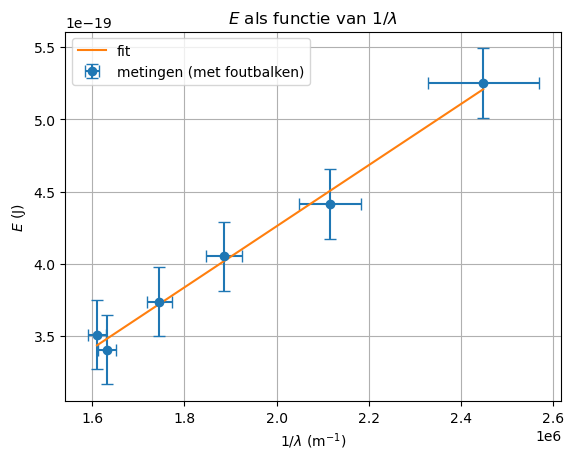

Fitresultaten (met onzekerheid):
a (h*c) = 2.1138e-25 ± 3.3e-26 J·m
b       = 3.2509e-21 ± 6.4e-20 J
h_fit   = 7.0506e-34 ± 1.1e-34 J·s
h (echt)= 6.6261e-34 J·s


In [119]:
plt.figure()
plt.title(r"$E$ als functie van $1/\lambda$")
plt.errorbar(inv_lam, E,
             xerr=inv_lam_err, yerr=E_err,
             fmt="o", capsize=4, label="metingen (met foutbalken)")

plt.plot(x_fit, y_fit, "-", label="fit")
plt.xlabel(r"$1/\lambda\ \mathrm{(m^{-1})}$")
plt.ylabel(r"$E\ \mathrm{(J)}$")
plt.grid(True)
plt.legend()
plt.show()

a_fit, b_fit = params
a_err = np.sqrt(cov[0,0])
b_err = np.sqrt(cov[1,1])

# h = a/c
h_fit = a_fit / c
h_err = a_err / c

print("Fitresultaten (met onzekerheid):")
print(f"a (h*c) = {a_fit:.4e} ± {a_err:.1e} J·m")
print(f"b       = {b_fit:.4e} ± {b_err:.1e} J")
print(f"h_fit   = {h_fit:.4e} ± {h_err:.1e} J·s")
print(f"h (echt)= {6.62607015e-34:.4e} J·s")


In [120]:
# Agreement analysis 

# geaccepteerde waarde
h_theory = 6.62607015e-34     # J s
u_h_theory = 0.0              # verwaarloosbaar

# verschil
Delta = h_fit - h_theory

# onzekerheid volgens foutpropagatie
u_Delta = np.sqrt(h_err**2 + u_h_theory**2)

print("Agreement analysis:")
print(f"Δ = {Delta:.3e} J·s")
print(f"u(Δ) = {u_Delta:.3e} J·s")
print(f"2·u(Δ) = {2*u_Delta:.3e} J·s")

# tegenstrijdigheidscriterium 
if abs(Delta) > 2 * u_Delta:
    print(" Resultaat is INCONSISTENT met de theorie")
else:
    print("Resultaat is CONSISTENT met de theorie")


Agreement analysis:
Δ = 4.245e-35 J·s
u(Δ) = 1.105e-34 J·s
2·u(Δ) = 2.209e-34 J·s
Resultaat is CONSISTENT met de theorie


In [121]:
# Code om accuracy te bepalen

# Relatieve afwijking
rel_af = np.abs(Delta)/h_fit

# accuracy
accuracy =  100 - (1-rel_af) * 100

print("De accuracy van ons experiment is: ", accuracy, "%")



De accuracy van ons experiment is:  6.021254623063584 %



**Notes:**  


## Discussion

De grootste bronnen van afwijking zijn experimentele beperkingen. Het bepalen van de drempelspanning is subjectief, omdat het moment waarop een LED “net zichtbaar” begint te branden moeilijk exact vast te stellen is. Daarnaast kunnen interne spanningsverliezen, temperatuurafhankelijkheid en verschillen in LED-constructie systematisch de gemeten spanningen verschuiven. Ook kan de bepaling van de golflengtes door meetfouten in de diffractie-opstelling bijdragen aan de onzekerheid.

Een mogelijke verbetering is het gebruik van een lichtsensor in plaats van visuele waarneming, waardoor de drempelspanning objectiever kan worden bepaald. Verder kan het gebruik van meer LED’s en nauwkeurigere golflengtemetingen de betrouwbaarheid van de lineaire fit vergroten. Ondanks deze beperkingen laat het experiment zien dat de Planckconstante met een relatief eenvoudige methode benaderd kan worden, waarbij de grootste beperkingen liggen in de meetprocedure en niet in het onderliggende fysische model. 

Om in de toekomst een onderzoek te doen wat dit onderzoek versterkt kan worden onderzocht wat voor invloed temperatuur heeft op de drempelspanning, de golflengte en de gevonden waarde van de constante van Planck. Zo wordt de nauwkeurigheid van dit experiment beter te begrijpen, en kan de constante van Planck opnieuw bepaald worden terwijl er meer rekening wordt gehouden met de effecten van de temperatuur.


## Conclusion

In dit experiment is de Planckconstante bepaald door drempelspanningsmetingen aan zes verschillende LED’s met golflengtes in het zichtbare spectrum. De experimentele waarde is


$$
h_\mathrm{exp} = (7.1 \pm 1.1)\times 10^{-34}\,\mathrm{J\,s},
$$



wat binnen $2\sigma$ consistent is met de literatuurwaarde $h=6.626\times 10^{-34}\,\mathrm{J\,s}$. De afwijking ten opzichte van de literatuurwaarde is ongeveer $6.0\%$, wat resulteert in een experimentele nauwkeurigheid van circa $94.0\%$.  Hiermee is aangetoond dat de experimentele waarde niet strijdig is met de literatuurwaarde voor de constante van Planck. 

De onzekerheid in het visueel bepalen van de drempelspanning is de grootste bron van onzekerheid in deze experimentele methode. Ook was er een relatief grote meetfout aanwezig in het meten van de relevante afstanden bij het bepalen van de golflengte. In een vervolgonderzoek kan de drempelspanning beter bepaald worden met behulp van een sensor. Daarnaast moet het licht uit de LED beter gecollimeerd worden om de dikte van de spectraallijnen te verkleinen. Dit verkleint de fout door de onzekerheid in de gemeten afstanden in de opstelling significant. In een vervolgonderzoek kan onderzocht worden wat voor invloed temperatuur heeft op de drempelspanning, de golflengte en de gevonden waarde voor de constante van Planck.


## Additional notes, remarks, explanations, thoughts etc